## Introdução
- Neste projeto, será desenvolvido um modelo de Machine Learning utilizando o algoritmo Random Forest para prever se um cliente permanecerá ou deixará o banco.

#### Objetivo do projeto
- O objetivo deste projeto é construir um modelo de classificação capaz de prever o churn dos clientes do ABC Multistate Bank.

#### Bibliotecas e instalação do dataset

In [384]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# Baixar o dataset
path = kagglehub.dataset_download("gauravtopre/bank-customer-churn-dataset")

print("Path to dataset files:", path)

# Mostrar os arquivos presentes na pasta
print(os.listdir(path))


Path to dataset files: C:\Users\italo\.cache\kagglehub\datasets\gauravtopre\bank-customer-churn-dataset\versions\1
['Bank Customer Churn Prediction.csv']


#### Leitura do dataset

In [385]:
#Fazendo a leitura dos arquivos
df = pd.read_csv(os.path.join(path, "Bank Customer Churn Prediction.csv"))

print(df.head())

   customer_id  credit_score country  gender  age  tenure    balance  \
0     15634602           619  France  Female   42       2       0.00   
1     15647311           608   Spain  Female   41       1   83807.86   
2     15619304           502  France  Female   42       8  159660.80   
3     15701354           699  France  Female   39       1       0.00   
4     15737888           850   Spain  Female   43       2  125510.82   

   products_number  credit_card  active_member  estimated_salary  churn  
0                1            1              1         101348.88      1  
1                1            0              1         112542.58      0  
2                3            1              0         113931.57      1  
3                2            0              0          93826.63      0  
4                1            1              1          79084.10      0  


#### Analise exploratória dos dados (Formato; Nomes das colunas; Valores ausentes e Numero de valores da variavel churn em %)

In [386]:
#analise geral

df = df.drop(columns=["customer_id"])

print("Dimensões do dataset:")
print(df.shape)

print("\nTipos das colunas:")
print(df.dtypes)

print("\nValores ausentes:")
print(df.isnull().sum())

print("\nDistribuição da variável alvo:")
print(df["churn"].value_counts(normalize=True)*100)


Dimensões do dataset:
(10000, 11)

Tipos das colunas:
credit_score          int64
country                 str
gender                  str
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
dtype: object

Valores ausentes:
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

Distribuição da variável alvo:
churn
0    79.63
1    20.37
Name: proportion, dtype: float64


#### Entendimento dos valores categóricos

In [387]:
#variaveis categoricas
print("Países:")
print(df["country"].value_counts())

print("\nGêneros:")
print(df["gender"].value_counts())

Países:
country
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Gêneros:
gender
Male      5457
Female    4543
Name: count, dtype: int64


#### Criação das variavéis X e y para trabalhar no modelo

In [388]:
#tratamento de dados
X = df.drop(columns=["churn"])
y = df["churn"]

variaveis_categoricas = ["gender", "country"]

#### Divisão entre treinamento e teste

Os dados foram divididos em 80% para treinamento e 20% para teste.

Dessa forma:

- 8.000 registros foram utilizados para treinar o modelo;
- 2.000 registros foram utilizados para avaliar seu desempenho.

In [389]:
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

print("Dados de treinamento:", X_treino.shape)
print("Dados de teste:", X_teste.shape)

print(y.value_counts())
print("Valores ausentes no alvo:", y.isnull().sum())

Dados de treinamento: (8000, 10)
Dados de teste: (2000, 10)
churn
0    7963
1    2037
Name: count, dtype: int64
Valores ausentes no alvo: 0


#### Valores categóricos em numéricos

In [390]:
pre_processamento = ColumnTransformer(transformers=[("categoricas",OneHotEncoder(handle_unknown="ignore", drop="first"),variaveis_categoricas)],remainder="passthrough")

#### Escolha do algoritmo Random Forest
A Random Forest combina os resultados de várias árvores de decisão. Cada árvore é treinada com diferentes amostras e subconjuntos de variáveis, e a previsão final é definida pela combinação das previsões dessas árvores.

Essa abordagem normalmente apresenta maior estabilidade e menor risco de sobreajuste do que uma única Árvore de Decisão.

Foi criada uma Pipeline para reunir o pré-processamento e o treinamento em uma única estrutura.

In [391]:
modelo_rf=Pipeline(steps=[("pre_processamento", pre_processamento),("modelo", RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
))])


In [392]:
modelo_rf.fit(X_treino, y_treino)

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


#### Realização das previsões
- Após o treinamento, o modelo foi utilizado para prever as classes dos clientes presentes no conjunto de teste.

In [393]:
previsoes_rf = modelo_rf.predict(X_teste)

probabilidades_rf = modelo_rf.predict_proba(X_teste)[:, 1]

#### Métricas de avaliação
- Acurácia: proporção total de previsões corretas;
- Precisão: entre os clientes classificados como churn, indica quantos realmente deixaram o banco;
- Recall: entre todos os clientes que deixaram o banco, indica quantos foram identificados pelo modelo;
- F1-score: média harmônica entre precisão e recall;
- AUC: capacidade do modelo de diferenciar clientes que permanecem daqueles que deixam o banco.

In [394]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,)

In [395]:
acuracia_rf= accuracy_score(y_teste, previsoes_rf)
precisao_rf=precision_score(y_teste, previsoes_rf, zero_division=0)
recall_rf=recall_score(y_teste, previsoes_rf, zero_division=0)
f1_rf=f1_score(y_teste, previsoes_rf, zero_division=0)
auc_rf = roc_auc_score(y_teste, probabilidades_rf)

### Análise dos resultados da Random Forest

In [396]:
print("RESULTADOS DA RANDOM FOREST")
print(f"Acurácia: {acuracia_rf:.3f}")
print(f"Precisão: {precisao_rf:.3f}")
print(f"Recall: {recall_rf:.3f}")
print(f"F1-score: {f1_rf:.3f}")
print(f"AUC: {auc_rf:.3f}")

RESULTADOS DA RANDOM FOREST
Acurácia: 0.864
Precisão: 0.786
Recall: 0.452
F1-score: 0.574
AUC: 0.857


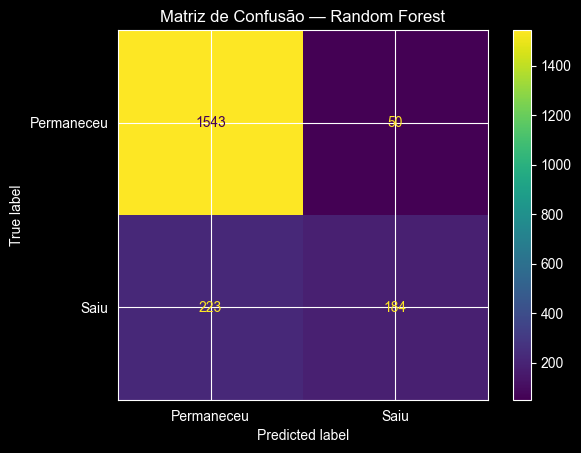

In [397]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

matriz = confusion_matrix(y_teste, previsoes_rf)

display_matriz = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=["Permaneceu", "Saiu"])

display_matriz.plot()
plt.title("Matriz de Confusão — Random Forest")
plt.show()

In [398]:
previsoes_treino = modelo_rf.predict(X_treino)

print("Acurácia no treinamento:",accuracy_score(y_treino, previsoes_treino))

print("Acurácia no teste:",accuracy_score(y_teste, previsoes_rf))

Acurácia no treinamento: 1.0
Acurácia no teste: 0.8635


Com o treinamento próximo de 1.00 e o teste em 0.868, existe sinal de sobreajuste. Testar um random forest mais controlado

Modelo treinado com sucesso!


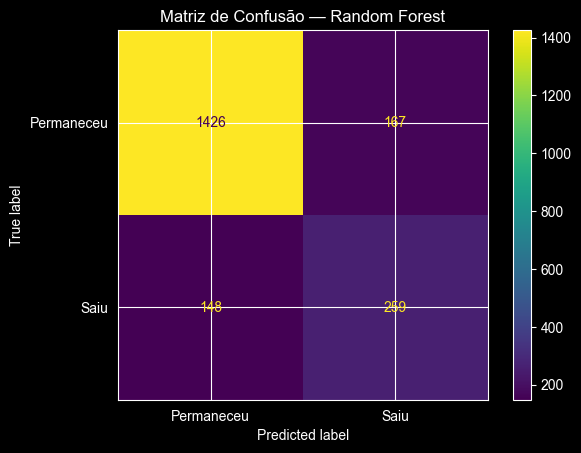

Acurácia no treinamento: 0.914375
Acurácia no teste: 0.8425


In [399]:
modelo_rf = Pipeline(
    steps=[
        ("pre_processamento", pre_processamento),
        ("modelo",RandomForestClassifier(
                n_estimators=500,
                max_depth=12,
                min_samples_split=10,
                min_samples_leaf=4,
                max_features="sqrt",
                class_weight="balanced",
                random_state=42,
                n_jobs=-1))])

modelo_rf.fit(X_treino, y_treino)

print("Modelo treinado com sucesso!")
previsoes_rf = modelo_rf.predict(X_teste)

probabilidades_rf = modelo_rf.predict_proba(X_teste)[:, 1]

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

matriz = confusion_matrix(y_teste, previsoes_rf)

display_matriz = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=["Permaneceu", "Saiu"])

display_matriz.plot()
plt.title("Matriz de Confusão — Random Forest")
plt.show()

previsoes_treino = modelo_rf.predict(X_treino)

print("Acurácia no treinamento:",accuracy_score(y_treino, previsoes_treino))

print("Acurácia no teste:",accuracy_score(y_teste, previsoes_rf))


In [400]:
acuracia_rf= accuracy_score(y_teste, previsoes_rf)
precisao_rf=precision_score(y_teste, previsoes_rf, zero_division=0)
recall_rf=recall_score(y_teste, previsoes_rf, zero_division=0)
f1_rf=f1_score(y_teste, previsoes_rf, zero_division=0)
auc_rf = roc_auc_score(y_teste, probabilidades_rf)

In [401]:
print("RESULTADOS DA RANDOM FOREST")
print(f"Acurácia: {acuracia_rf:.3f}")
print(f"Precisão: {precisao_rf:.3f}")
print(f"Recall: {recall_rf:.3f}")
print(f"F1-score: {f1_rf:.3f}")
print(f"AUC: {auc_rf:.3f}")

RESULTADOS DA RANDOM FOREST
Acurácia: 0.843
Precisão: 0.608
Recall: 0.636
F1-score: 0.622
AUC: 0.864


Ajuste fino da Random Forest

Após a avaliação do modelo inicial, foi realizado um segundo teste com ajustes nos hiperparâmetros da Random Forest. O objetivo foi reduzir o sobreajuste e melhorar principalmente a identificação dos clientes que realmente deixaram o banco.

No primeiro teste, o modelo apresentou:

- Acurácia de 86,8%;
- Precisão de 78,2%;
- Recall de 48,4%;
- F1-score de 59,8%.

Apesar da boa acurácia e precisão, o recall mostrou que o modelo identificava menos da metade dos clientes que realmente apresentaram churn. Por esse motivo, foram realizados ajustes em parâmetros responsáveis pela quantidade e pela complexidade das árvores, como número de estimadores, profundidade máxima, quantidade mínima de amostras por divisão e peso atribuído às classes.

Após os ajustes, o modelo apresentou:

- Acurácia de 84,3% ;
- Precisão de 60,8%;
- Recall de 63,6%;
- F1-score de 62,2%;
- AUC de 86,4%.

Embora o modelo ajustado tenha produzido mais falsos positivos, ou seja, tenha classificado alguns clientes como possíveis casos de churn sem que eles realmente tenham deixado o banco, houve uma redução esperada nos falsos negativos. Para uma instituição bancária, essa mudança pode ser vantajosa, pois permite identificar mais clientes em risco e realizar ações de retenção antecipadamente.

## Conclusão final

Para o objetivo deste projeto, o modelo ajustado foi considerado mais adequado. Apesar da pequena redução na acurácia, ele consegue identificar uma proporção maior dos clientes que realmente apresentam churn, permitindo que o banco desenvolva estratégias de retenção antes que esses clientes encerrem seu relacionamento com a instituição.